In [1]:
import os

os.listdir('/content')

['.config', 'mipzipk.zip', 'sample_data']

In [2]:
import zipfile

zip_path = "/content/mipzipk.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted!")

Dataset extracted!


In [3]:
for root, dirs, files in os.walk("/content/dataset"):
    print(root, "—", len(files), "files")

/content/dataset — 12 files
/content/dataset/Normal — 0 files
/content/dataset/Normal/Normal — 0 files
/content/dataset/Normal/Normal/image — 100 files
/content/dataset/Normal/Normal/segmentation — 0 files
/content/dataset/Normal/Normal/segmentation/outline — 100 files
/content/dataset/Normal/Normal/segmentation/liver — 100 files
/content/dataset/failed1 — 735 files
/content/dataset/failed2 — 81 files
/content/dataset/masks — 735 files
/content/dataset/Malignant — 0 files
/content/dataset/Malignant/Malignant — 0 files
/content/dataset/Malignant/Malignant/image — 435 files
/content/dataset/Malignant/Malignant/segmentation — 0 files
/content/dataset/Malignant/Malignant/segmentation/mass — 435 files
/content/dataset/Malignant/Malignant/segmentation/outline — 435 files
/content/dataset/Malignant/Malignant/segmentation/liver — 432 files
/content/dataset/Benign — 0 files
/content/dataset/Benign/Benign — 0 files
/content/dataset/Benign/Benign/image — 200 files
/content/dataset/Benign/Benign/s

In [5]:
print("Image files:", os.listdir(img_dir)[:5])
print("Mask files:", os.listdir(mask_dir)[:5])

NameError: name 'img_dir' is not defined

In [6]:
import os

mask_root = "/content/masks_generated"
os.makedirs(mask_root, exist_ok=True)

print("Mask folder created")

Mask folder created


In [7]:
import cv2
import numpy as np

def create_tumor_mask(img):

    # 1️⃣ Speckle noise reduction
    smooth = cv2.medianBlur(img, 5)

    # 2️⃣ Log transform (enhancement)
    c = 255 / np.log(1 + np.max(smooth))
    log_img = c * np.log(1 + smooth)
    log_img = np.array(log_img, dtype=np.uint8)

    # 3️⃣ Histogram equalization
    eq = cv2.equalizeHist(log_img)

    # 4️⃣ Otsu threshold (region segmentation)
    _, mask = cv2.threshold(eq, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 5️⃣ Morphology cleanup
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

Text(0.5, 1.0, 'Generated Mask')

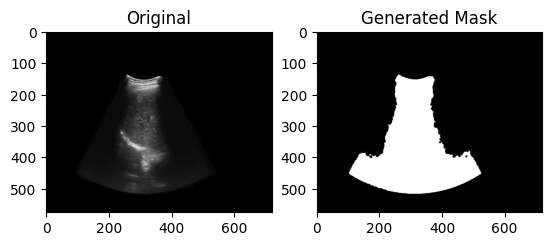

In [8]:
import matplotlib.pyplot as plt

img_dir = "/content/dataset/Benign/Benign/image"

sample = os.listdir(img_dir)[0]

img = cv2.imread(os.path.join(img_dir, sample), 0)

mask = create_tumor_mask(img)

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Generated Mask")

In [9]:
classes = ["Normal", "Benign", "Malignant"]

for cls in classes:

    img_dir = f"/content/dataset/{cls}/{cls}/image"
    save_dir = f"/content/masks_generated/{cls}"
    os.makedirs(save_dir, exist_ok=True)

    for file in os.listdir(img_dir):

        img = cv2.imread(os.path.join(img_dir, file), 0)

        # Normal class → no tumor
        if cls == "Normal":
            mask = np.zeros_like(img)
        else:
            mask = create_tumor_mask(img)

        cv2.imwrite(os.path.join(save_dir, file), mask)

print("All masks generated!")

/tmp/ipython-input-705/1855411697.py:10: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(smooth))
/tmp/ipython-input-705/1855411697.py:10: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(smooth))
/tmp/ipython-input-705/1855411697.py:11: RuntimeWarning: divide by zero encountered in log
  log_img = c * np.log(1 + smooth)
/tmp/ipython-input-705/1855411697.py:11: RuntimeWarning: invalid value encountered in multiply
  log_img = c * np.log(1 + smooth)
/tmp/ipython-input-705/1855411697.py:12: RuntimeWarning: invalid value encountered in cast
  log_img = np.array(log_img, dtype=np.uint8)


All masks generated!


In [10]:
import os
import shutil
from sklearn.model_selection import train_test_split

In [11]:
image_paths = []
mask_paths = []

classes = ["Normal", "Benign", "Malignant"]

for cls in classes:

    img_dir = f"/content/dataset/{cls}/{cls}/image"
    mask_dir = f"/content/masks_generated/{cls}"

    for file in os.listdir(img_dir):

        image_paths.append(os.path.join(img_dir, file))
        mask_paths.append(os.path.join(mask_dir, file))

In [12]:
train_imgs, test_imgs, train_masks, test_masks = train_test_split(
    image_paths, mask_paths,
    test_size=0.2,
    random_state=42
)

In [13]:
base = "/content/dataset_split"

folders = [
    "train/images", "train/masks",
    "test/images", "test/masks"
]

for f in folders:
    os.makedirs(os.path.join(base, f), exist_ok=True)

In [14]:
for img, mask in zip(train_imgs, train_masks):
    shutil.copy(img, base + "/train/images")
    shutil.copy(mask, base + "/train/masks")

In [15]:
for img, mask in zip(test_imgs, test_masks):
    shutil.copy(img, base + "/test/images")
    shutil.copy(mask, base + "/test/masks")

In [16]:
print("Train images:", len(os.listdir(base + "/train/images")))
print("Test images:", len(os.listdir(base + "/test/images")))

Train images: 379
Test images: 123


Text(0.5, 1.0, 'Mask')

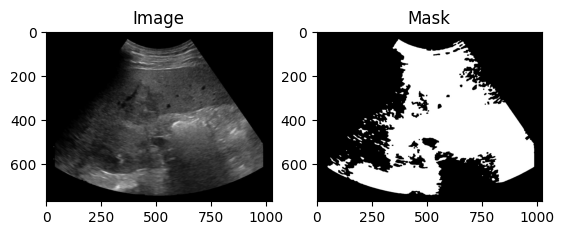

In [17]:
import random
import cv2
import matplotlib.pyplot as plt
import os

train_img_dir = "/content/dataset_split/train/images"
train_mask_dir = "/content/dataset_split/train/masks"

files = os.listdir(train_img_dir)

sample = random.choice(files)

img = cv2.imread(os.path.join(train_img_dir, sample), 0)
mask = cv2.imread(os.path.join(train_mask_dir, sample), 0)

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [19]:
train_img_dir = "/content/dataset_split/train/images"
train_mask_dir = "/content/dataset_split/train/masks"

test_img_dir = "/content/dataset_split/test/images"
test_mask_dir = "/content/dataset_split/test/masks"

In [20]:
def load_data(img_dir, mask_dir, size=(256,256)):

    images = []
    masks = []

    files = os.listdir(img_dir)

    for file in files:

        img = cv2.imread(os.path.join(img_dir, file), 0)
        mask = cv2.imread(os.path.join(mask_dir, file), 0)

        img = cv2.resize(img, size)
        mask = cv2.resize(mask, size)

        img = img / 255.0
        mask = mask / 255.0

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

In [21]:
X_train, Y_train = load_data(train_img_dir, train_mask_dir)
X_test, Y_test = load_data(test_img_dir, test_mask_dir)

print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(379, 256, 256) (379, 256, 256)
(123, 256, 256) (123, 256, 256)


Text(0.5, 1.0, 'Train Mask')

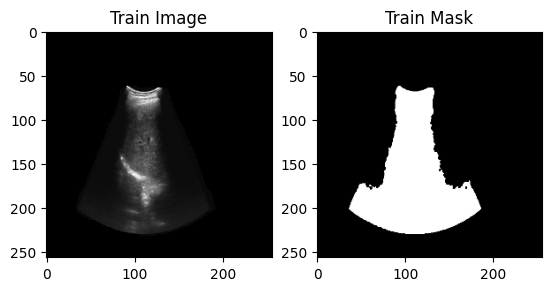

In [22]:
plt.subplot(1,2,1)
plt.imshow(X_train[0], cmap='gray')
plt.title("Train Image")

plt.subplot(1,2,2)
plt.imshow(Y_train[0], cmap='gray')
plt.title("Train Mask")

In [23]:
def classical_segmentation(img):

    img = (img * 255).astype(np.uint8)

    blur = cv2.medianBlur(img, 5)

    _, mask = cv2.threshold(blur, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return mask / 255.0

Text(0.5, 1.0, 'Classical Prediction')

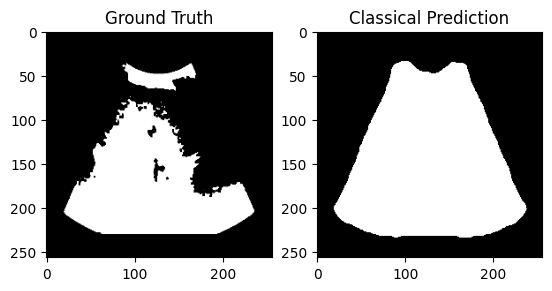

In [24]:
pred_mask = classical_segmentation(X_test[0])

plt.subplot(1,2,1)
plt.imshow(Y_test[0], cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,2,2)
plt.imshow(pred_mask, cmap='gray')
plt.title("Classical Prediction")

In [25]:
def dice_score(true, pred):

    true = true.flatten()
    pred = pred.flatten()

    intersection = np.sum(true * pred)

    return (2 * intersection) / (np.sum(true) + np.sum(pred) + 1e-8)

In [26]:
scores = []

for i in range(len(X_test)):

    pred = classical_segmentation(X_test[i])
    score = dice_score(Y_test[i], pred)
    scores.append(score)

print("Average Dice Score:", np.mean(scores))

Average Dice Score: 0.6361448754633133


In [27]:
!pip install scikit-image

In [28]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian

def active_contour_segmentation(img):

    img_uint = (img * 255).astype(np.uint8)

    # Initial circle
    s = np.linspace(0, 2*np.pi, 400)
    r = img_uint.shape[0]/2 + img_uint.shape[0]/4*np.sin(s)
    c = img_uint.shape[1]/2 + img_uint.shape[1]/4*np.cos(s)
    init = np.array([r, c]).T

    snake = active_contour(
        gaussian(img_uint, 3),
        init,
        alpha=0.015,
        beta=10,
        gamma=0.001
    )

    mask = np.zeros_like(img_uint)

    for point in snake.astype(int):
        mask[point[0], point[1]] = 255

    return mask / 255.0

Text(0.5, 1.0, 'Active Contour')

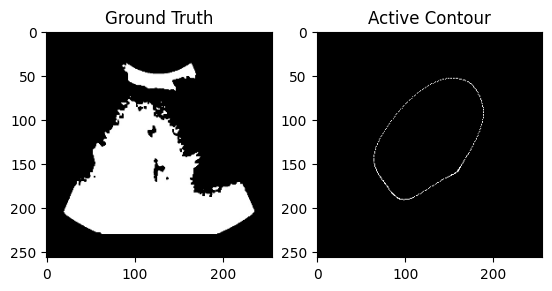

In [29]:
pred = active_contour_segmentation(X_test[0])

plt.subplot(1,2,1)
plt.imshow(Y_test[0], cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,2,2)
plt.imshow(pred, cmap='gray')
plt.title("Active Contour")

In [30]:
scores_ac = []

for i in range(len(X_test)):

    pred = active_contour_segmentation(X_test[i])
    score = dice_score(Y_test[i], pred)
    scores_ac.append(score)

print("Active Contour Dice:", np.mean(scores_ac))

Active Contour Dice: 0.01135618806696536


In [31]:
X_train = X_train[..., np.newaxis]
Y_train = Y_train[..., np.newaxis]

X_test = X_test[..., np.newaxis]
Y_test = Y_test[..., np.newaxis]

print(X_train.shape)

(379, 256, 256, 1)


In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [33]:
def build_unet(input_shape=(256,256,1)):

    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(c5)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(u3)
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return models.Model(inputs, outputs)

In [34]:
def dice_loss(y_true, y_pred):

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)

    return 1 - (2. * intersection + 1) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1)

In [35]:
model = build_unet()

model.compile(
    optimizer='adam',
    loss=dice_loss,
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_9[0][0]  

 Total params: 487,009 (1.86 MB)

 Trainable params: 487,009 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    X_train, Y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=8
)

Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 40s 455ms/step - accuracy: 0.4631 - loss: 0.5397 - val_accuracy: 0.8553 - val_loss: 0.2196
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8446 - loss: 0.2537 - val_accuracy: 0.8561 - val_loss: 0.2168
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8482 - loss: 0.2449 - val_accuracy: 0.8651 - val_loss: 0.2083
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8505 - loss: 0.2288 - val_accuracy: 0.8757 - val_loss: 0.1936
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8716 - loss: 0.1985 - val_accuracy: 0.8689 - val_loss: 0.1988
Epoch 6/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.8678 - loss: 0.2095 - val_accuracy: 0.8735 - val_loss: 0.1932
Epoch 7/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8581 - loss: 0.2201 - val_accuracy: 0.8721 - val_loss: 0.1952
Epoch 8/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8737 - loss: 0.1919 - val_accuracy: 0.8724 -

In [37]:
preds = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step


In [38]:
preds_bin = (preds > 0.5).astype(np.float32)

In [39]:
dice_scores = []

for i in range(len(preds_bin)):
    score = dice_score(Y_test[i], preds_bin[i])
    dice_scores.append(score)

print("UNet Dice Score:", np.mean(dice_scores))

UNet Dice Score: 0.6277452028310349


Text(0.5, 1.0, 'UNet Prediction')

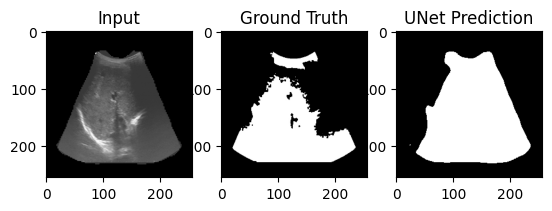

In [40]:
plt.subplot(1,3,1)
plt.imshow(X_test[0].squeeze(), cmap='gray')
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(Y_test[0].squeeze(), cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(preds_bin[0].squeeze(), cmap='gray')
plt.title("UNet Prediction")

In [41]:
def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    dice = (2. * intersection + 1) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1
    )

    return bce + (1 - dice)

In [42]:
model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=['accuracy']
)

In [43]:
epochs = 40

In [44]:
non_empty_indices = [i for i in range(len(Y_train))
                     if np.sum(Y_train[i]) > 0]

X_train_filtered = X_train[non_empty_indices]
Y_train_filtered = Y_train[non_empty_indices]

In [45]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(X_train_filtered)

In [46]:
history = model.fit(
    X_train_filtered,
    Y_train_filtered,
    epochs=40,
    batch_size=8,
    validation_split=0.1
)

Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 424ms/step - accuracy: 0.9046 - loss: 0.4941 - val_accuracy: 0.9150 - val_loss: 0.2648
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9064 - loss: 0.2967 - val_accuracy: 0.9202 - val_loss: 0.2391
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9113 - loss: 0.2756 - val_accuracy: 0.9235 - val_loss: 0.2244
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9165 - loss: 0.2509 - val_accuracy: 0.9242 - val_loss: 0.2256
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9156 - loss: 0.2504 - val_accuracy: 0.9226 - val_loss: 0.2221
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9199 - loss: 0.2365 - val_accuracy: 0.9255 - val_loss: 0.2136
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9161 - loss: 0.2428 - val_accuracy: 0.9230 - val_loss: 0.2192
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9178 - loss: 0.2378 - val_accuracy: 0.9158 -

In [47]:
import numpy as np

def dice_score(true, pred):

    true = true.astype(np.float32).flatten()
    pred = pred.astype(np.float32).flatten()

    intersection = np.sum(true * pred)

    return (2. * intersection) / (
        np.sum(true) + np.sum(pred) + 1e-8
    )

In [48]:
scores = []

for i in range(len(preds_bin)):
    score = dice_score(Y_test[i], preds_bin[i])
    scores.append(score)

print("Average Dice Score:", np.mean(scores))

Average Dice Score: 0.62774515


In [49]:
preds_bin = (preds > 0.5).astype(np.float32)

In [50]:
for i in range(5):
    print(f"Image {i} Dice:", dice_score(Y_test[i], preds_bin[i]))

Image 0 Dice: 0.80044806
Image 1 Dice: 0.93329203
Image 2 Dice: 0.0
Image 3 Dice: 0.92719394
Image 4 Dice: 0.8236855


In [52]:
print("Average Dice Score:", np.mean(scores))

Average Dice Score: 0.62774515


In [53]:
classical_dice = np.mean(scores)   # from classical model

In [54]:
active_dice = np.mean(scores_ac)   # from active contour model

In [55]:
unet_dice = np.mean(dice_scores)   # from UNet evaluation

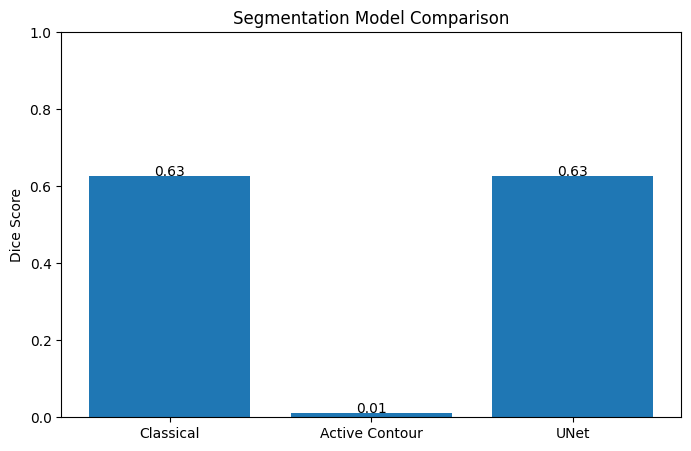

In [56]:
import matplotlib.pyplot as plt

models = ["Classical", "Active Contour", "UNet"]
dice_scores_plot = [classical_dice, active_dice, unet_dice]

plt.figure(figsize=(8,5))
bars = plt.bar(models, dice_scores_plot)

plt.title("Segmentation Model Comparison")
plt.ylabel("Dice Score")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha='center')

plt.show()

In [57]:
print("Classical:", classical_dice)
print("Active Contour:", active_dice)
print("UNet:", unet_dice)

Classical: 0.62774515
Active Contour: 0.01135618806696536
UNet: 0.6277452028310349


In [58]:
best_mask = preds_bin[0]   # example UNet prediction

In [59]:
import numpy as np

def tumor_area(mask):
    return np.sum(mask > 0)

area = tumor_area(best_mask)

print("Tumor Area (pixels):", area)

Tumor Area (pixels): 26405


In [60]:
import cv2
import numpy as np

def boundary_irregularity(mask):

    mask_uint = (mask * 255).astype(np.uint8)

    contours, _ = cv2.findContours(
        mask_uint, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return 0

    contour = max(contours, key=cv2.contourArea)

    perimeter = cv2.arcLength(contour, True)
    area = cv2.contourArea(contour)

    if area == 0:
        return 0

    irregularity = (perimeter ** 2) / (4 * np.pi * area)

    return irregularity

irr = boundary_irregularity(best_mask)

print("Boundary Irregularity Index:", irr)

Boundary Irregularity Index: 1.5994419238792366


In [61]:
def tumor_volume(masks):
    return sum(np.sum(m > 0) for m in masks)

In [62]:
def stage_prediction(area, irregularity):

    if area < 2000 and irregularity < 1.5:
        return "Early Stage"

    elif area < 5000:
        return "Intermediate Stage"

    else:
        return "Advanced Stage"

In [63]:
stage = stage_prediction(area, irr)
print("Predicted Stage:", stage)

Predicted Stage: Advanced Stage


In [64]:
import matplotlib.pyplot as plt

i = 0   # change index to view different test images

img = X_test[i].squeeze()
gt = Y_test[i].squeeze()

classical_pred = classical_segmentation(X_test[i]).squeeze()
active_pred = active_contour_segmentation(X_test[i]).squeeze()
unet_pred = preds_bin[i].squeeze()

plt.figure(figsize=(15,5))

titles = [
    "Input Image",
    "Ground Truth",
    "Classical",
    "Active Contour",
    "UNet"
]

images = [
    img,
    gt,
    classical_pred,
    active_pred,
    unet_pred
]

for j in range(5):
    plt.subplot(1,5,j+1)
    plt.imshow(images[j], cmap='gray')
    plt.title(titles[j])
    plt.axis('off')

plt.show()

IndexError: index 1 is out of bounds for axis 2 with size 1

In [65]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian

def active_contour_segmentation(img):

    # Convert from (H,W,1) → (H,W)
    if img.ndim == 3:
        img = img.squeeze()

    img_uint = (img * 255).astype(np.uint8)

    s = np.linspace(0, 2*np.pi, 400)
    r = img_uint.shape[0]/2 + img_uint.shape[0]/4*np.sin(s)
    c = img_uint.shape[1]/2 + img_uint.shape[1]/4*np.cos(s)
    init = np.array([r, c]).T

    snake = active_contour(
        gaussian(img_uint, 3),
        init,
        alpha=0.015,
        beta=10,
        gamma=0.001
    )

    mask = np.zeros_like(img_uint)

    for point in snake.astype(int):
        mask[point[0], point[1]] = 255

    return mask / 255.0

In [66]:
active_pred = active_contour_segmentation(X_test[i]).squeeze()

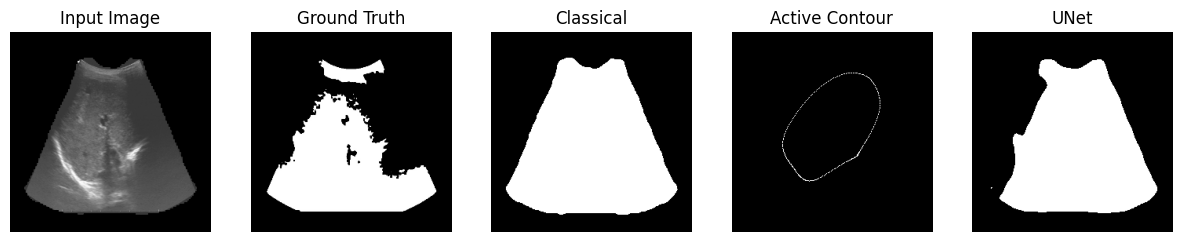

In [67]:
import matplotlib.pyplot as plt

i = 0   # change index to view different test images

img = X_test[i].squeeze()
gt = Y_test[i].squeeze()

classical_pred = classical_segmentation(X_test[i]).squeeze()
active_pred = active_contour_segmentation(X_test[i]).squeeze()
unet_pred = preds_bin[i].squeeze()

plt.figure(figsize=(15,5))

titles = [
    "Input Image",
    "Ground Truth",
    "Classical",
    "Active Contour",
    "UNet"
]

images = [
    img,
    gt,
    classical_pred,
    active_pred,
    unet_pred
]

for j in range(5):
    plt.subplot(1,5,j+1)
    plt.imshow(images[j], cmap='gray')
    plt.title(titles[j])
    plt.axis('off')

plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

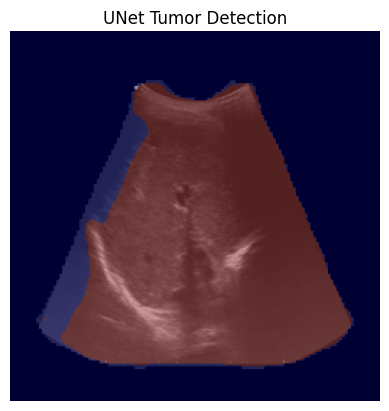

In [68]:
plt.imshow(img, cmap='gray')
plt.imshow(unet_pred, cmap='jet', alpha=0.4)
plt.title("UNet Tumor Detection")
plt.axis('off')

In [69]:
def iou_score(true, pred):

    true = true.flatten()
    pred = pred.flatten()

    intersection = np.sum(true * pred)
    union = np.sum(true) + np.sum(pred) - intersection

    return intersection / (union + 1e-8)

In [70]:
iou_scores = []

for i in range(len(preds_bin)):
    iou_scores.append(iou_score(Y_test[i], preds_bin[i]))

unet_iou = np.mean(iou_scores)

print("UNet IoU:", unet_iou)

UNet IoU: 0.5713251283334136


In [71]:
def pixel_accuracy(true, pred):
    return np.mean(true == pred)

acc_scores = []

for i in range(len(preds_bin)):
    acc_scores.append(pixel_accuracy(Y_test[i], preds_bin[i]))

unet_acc = np.mean(acc_scores)

print("UNet Accuracy:", unet_acc)

UNet Accuracy: 0.8539143383987551


In [72]:
print("===== FINAL RESULTS =====")

print("Classical Dice:", classical_dice)
print("Active Contour Dice:", active_dice)
print("UNet Dice:", unet_dice)

print("UNet IoU:", unet_iou)
print("UNet Accuracy:", unet_acc)

===== FINAL RESULTS =====
Classical Dice: 0.62774515
Active Contour Dice: 0.01135618806696536
UNet Dice: 0.6277452028310349
UNet IoU: 0.5713251283334136
UNet Accuracy: 0.8539143383987551


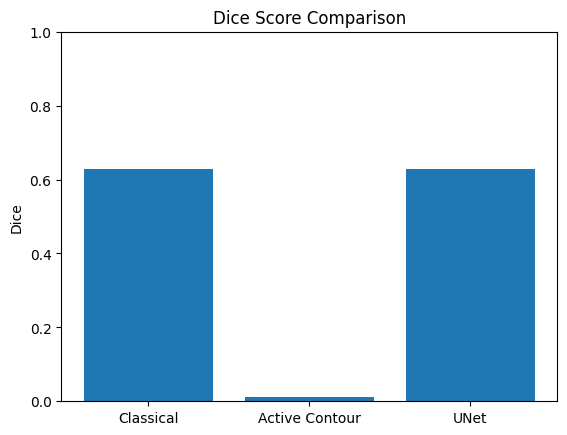

In [73]:
models = ["Classical", "Active Contour", "UNet"]
dice_scores = [classical_dice, active_dice, unet_dice]

plt.bar(models, dice_scores)
plt.title("Dice Score Comparison")
plt.ylabel("Dice")
plt.ylim(0,1)
plt.show()

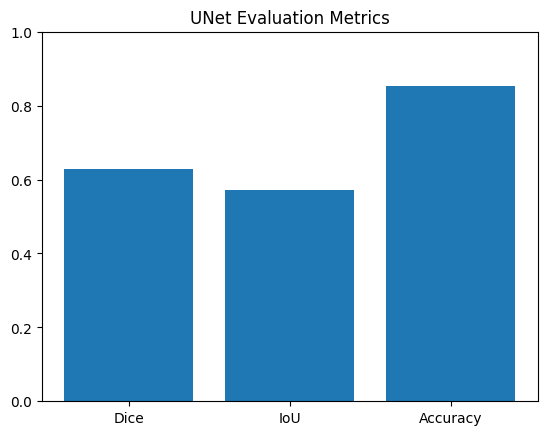

In [74]:
metrics = ["Dice", "IoU", "Accuracy"]
values = [unet_dice, unet_iou, unet_acc]

plt.bar(metrics, values)
plt.title("UNet Evaluation Metrics")
plt.ylim(0,1)
plt.show()

In [75]:
import numpy as np

non_empty_indices = [
    i for i in range(len(Y_train))
    if np.sum(Y_train[i]) > 0
]

X_train = X_train[non_empty_indices]
Y_train = Y_train[non_empty_indices]

print("Training samples after removing Normal:",
      len(X_train))

Training samples after removing Normal: 305


In [76]:
import cv2

def advanced_preprocess(img):

    img = (img * 255).astype(np.uint8)

    # Speckle reduction (bilateral filter)
    img = cv2.bilateralFilter(img, 9, 75, 75)

    # CLAHE (best for ultrasound)
    clahe = cv2.createCLAHE(clipLimit=2.0,
                            tileGridSize=(8,8))
    img = clahe.apply(img)

    return img / 255.0

In [77]:
X_train = np.array([advanced_preprocess(x.squeeze())
                    for x in X_train])[..., np.newaxis]

X_test = np.array([advanced_preprocess(x.squeeze())
                   for x in X_test])[..., np.newaxis]

In [78]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

In [79]:
import tensorflow as tf
from tensorflow.keras import layers

def attention_gate(x, g, filters):

    theta_x = layers.Conv2D(filters, 1, padding='same')(x)
    phi_g = layers.Conv2D(filters, 1, padding='same')(g)

    add = layers.Add()([theta_x, phi_g])
    act = layers.Activation('relu')(add)

    psi = layers.Conv2D(1, 1, padding='same')(act)
    psi = layers.Activation('sigmoid')(psi)

    return layers.Multiply()([x, psi])

In [80]:
def conv_block(x, filters):

    x = layers.Conv2D(filters, 3, padding='same',
                      activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same',
                      activation='relu')(x)

    return x

In [81]:
def build_attention_unet(input_shape=(256,256,1)):

    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 16)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 32)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 64)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = conv_block(p3, 128)

    # Decoder with Attention
    u1 = layers.UpSampling2D()(b)
    att1 = attention_gate(c3, u1, 64)
    u1 = layers.Concatenate()([u1, att1])
    c4 = conv_block(u1, 64)

    u2 = layers.UpSampling2D()(c4)
    att2 = attention_gate(c2, u2, 32)
    u2 = layers.Concatenate()([u2, att2])
    c5 = conv_block(u2, 32)

    u3 = layers.UpSampling2D()(c5)
    att3 = attention_gate(c1, u3, 16)
    u3 = layers.Concatenate()([u3, att3])
    c6 = conv_block(u3, 16)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return tf.keras.Model(inputs, outputs)

In [82]:
model = build_attention_unet()

model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=['accuracy']
)

In [83]:
from sklearn.model_selection import train_test_split

X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_train, Y_train,
    test_size=0.1,
    random_state=42
)

In [84]:
train_gen = datagen.flow(
    X_tr, Y_tr,
    batch_size=8
)

In [85]:
val_gen = ImageDataGenerator().flow(
    X_val, Y_val,
    batch_size=8
)

In [86]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40
)

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 337ms/step - accuracy: 0.7016 - loss: 1.1782 - val_accuracy: 0.8815 - val_loss: 0.7186
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7400 - loss: 0.9685 - val_accuracy: 0.8707 - val_loss: 0.6574
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7535 - loss: 0.8940 - val_accuracy: 0.8497 - val_loss: 0.6133
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.7685 - loss: 0.8374 - val_accuracy: 0.8175 - val_loss: 0.6891
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7660 - loss: 0.8461 - val_accuracy: 0.8486 - val_loss: 0.6345
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7855 - loss: 0.7891 - val_accuracy: 0.8328 - val_loss: 0.5916
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7789 - loss: 0.7965 - val_accuracy: 0.8507 - val_loss: 0.5919
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7666 - loss: 0.8385 - val_accuracy: 0.8482 - val_loss: 

In [87]:
preds_att = model.predict(X_test)
preds_att_bin = (preds_att > 0.5).astype(np.float32)

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


In [88]:
import tensorflow as tf
from tensorflow.keras import layers

def residual_block(x, filters):

    shortcut = layers.Conv2D(filters, 1, padding='same')(x)

    x = layers.Conv2D(filters, 3, padding='same',
                      activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

In [89]:
def attention_gate(x, g, filters):

    theta_x = layers.Conv2D(filters, 1, padding='same')(x)
    phi_g = layers.Conv2D(filters, 1, padding='same')(g)

    add = layers.Add()([theta_x, phi_g])
    act = layers.Activation('relu')(add)

    psi = layers.Conv2D(1, 1, padding='same')(act)
    psi = layers.Activation('sigmoid')(psi)

    return layers.Multiply()([x, psi])

In [90]:
def build_hybrid_model(input_shape=(256,256,1)):

    inputs = layers.Input(input_shape)

    # Encoder (Residual)
    c1 = residual_block(inputs, 16)
    p1 = layers.MaxPooling2D()(c1)

    c2 = residual_block(p1, 32)
    p2 = layers.MaxPooling2D()(c2)

    c3 = residual_block(p2, 64)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = residual_block(p3, 128)

    # Decoder with Attention
    u1 = layers.UpSampling2D()(b)
    att1 = attention_gate(c3, u1, 64)
    u1 = layers.Concatenate()([u1, att1])
    c4 = residual_block(u1, 64)

    u2 = layers.UpSampling2D()(c4)
    att2 = attention_gate(c2, u2, 32)
    u2 = layers.Concatenate()([u2, att2])
    c5 = residual_block(u2, 32)

    u3 = layers.UpSampling2D()(c5)
    att3 = attention_gate(c1, u3, 16)
    u3 = layers.Concatenate()([u3, att3])
    c6 = residual_block(u3, 16)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return tf.keras.Model(inputs, outputs)

In [91]:
hybrid_model = build_hybrid_model()

hybrid_model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=['accuracy']
)

In [92]:
history_hybrid = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40
)

Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 417ms/step - accuracy: 0.7018 - loss: 1.1183 - val_accuracy: 0.8616 - val_loss: 0.6245
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.7429 - loss: 0.9279 - val_accuracy: 0.8395 - val_loss: 0.5768
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.7532 - loss: 0.8928 - val_accuracy: 0.8478 - val_loss: 0.5537
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.7500 - loss: 0.8795 - val_accuracy: 0.8659 - val_loss: 0.6260
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.7655 - loss: 0.8550 - val_accuracy: 0.8496 - val_loss: 0.5940
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.7797 - loss: 0.7979 - val_accuracy: 0.8381 - val_loss: 0.6277
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.7750 - loss: 0.8094 - val_accuracy: 0.8480 - val_loss: 0.6171
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.7734 - loss: 0.8117 - val_accuracy: 0.8458 -

In [93]:
preds_hybrid = hybrid_model.predict(X_test)
preds_hybrid_bin = (preds_hybrid > 0.5).astype(np.float32)

hybrid_dice_scores = [
    dice_score(Y_test[i], preds_hybrid_bin[i])
    for i in range(len(preds_hybrid_bin))
]

hybrid_dice = np.mean(hybrid_dice_scores)

print("Hybrid Model Dice:", hybrid_dice)

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
Hybrid Model Dice: 0.5702542


In [94]:
import matplotlib.pyplot as plt

i = 0   # change to view different cases

img = X_test[i].squeeze()
gt = Y_test[i].squeeze()

classical_pred = classical_segmentation(X_test[i]).squeeze()
active_pred = active_contour_segmentation(X_test[i]).squeeze()
unet_pred = preds_bin[i].squeeze()
att_pred = preds_att_bin[i].squeeze()
hybrid_pred = preds_hybrid_bin[i].squeeze()

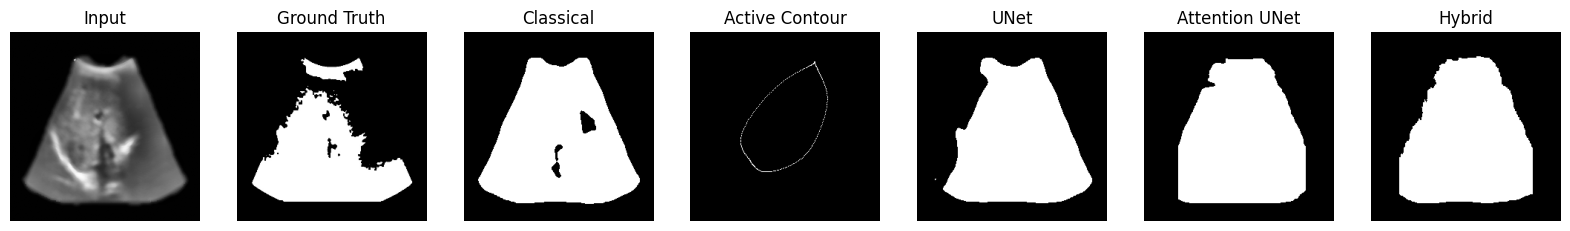

In [95]:
plt.figure(figsize=(20,5))

titles = [
    "Input",
    "Ground Truth",
    "Classical",
    "Active Contour",
    "UNet",
    "Attention UNet",
    "Hybrid"
]

images = [
    img,
    gt,
    classical_pred,
    active_pred,
    unet_pred,
    att_pred,
    hybrid_pred
]

for j in range(7):
    plt.subplot(1,7,j+1)
    plt.imshow(images[j], cmap='gray')
    plt.title(titles[j])
    plt.axis('off')

plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

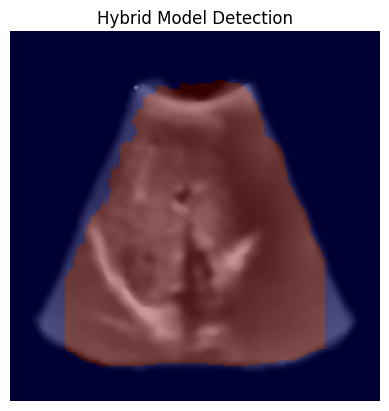

In [96]:
plt.imshow(img, cmap='gray')
plt.imshow(hybrid_pred, cmap='jet', alpha=0.4)
plt.title("Hybrid Model Detection")
plt.axis('off')

In [97]:
for i in range(5):
    # repeat plotting code
    plt.savefig(f"comparison_{i}.png")

<Figure size 640x480 with 0 Axes>

In [98]:
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # smaller LR
    loss=bce_dice_loss,
    metrics=['accuracy']
)

In [99]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [100]:
history = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,
    callbacks=[callback]
)

Epoch 1/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 348ms/step - accuracy: 0.7850 - loss: 0.7670 - val_accuracy: 0.8558 - val_loss: 0.5672
Epoch 2/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.7849 - loss: 0.7726 - val_accuracy: 0.8546 - val_loss: 0.5797
Epoch 3/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.7904 - loss: 0.7588 - val_accuracy: 0.8520 - val_loss: 0.5621
Epoch 4/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.7855 - loss: 0.7665 - val_accuracy: 0.8540 - val_loss: 0.5785
Epoch 5/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.7867 - loss: 0.7672 - val_accuracy: 0.8512 - val_loss: 0.5773
Epoch 6/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.7877 - loss: 0.7518 - val_accuracy: 0.8552 - val_loss: 0.5732
Epoch 7/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.7851 - loss: 0.7732 - val_accuracy: 0.8588 - val_loss: 0.5685
Epoch 8/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.7937 - loss: 0.7549 - val_accuracy: 0.8546 -

In [101]:
img = cv2.GaussianBlur(img, (5,5), 0)
img = cv2.addWeighted(img, 1.5, img, -0.5, 0)

In [102]:
import tensorflow as tf

def focal_tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, gamma=0.75):

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    TP = tf.reduce_sum(y_true * y_pred)
    FN = tf.reduce_sum(y_true * (1 - y_pred))
    FP = tf.reduce_sum((1 - y_true) * y_pred)

    tversky = (TP + 1) / (TP + alpha * FN + beta * FP + 1)

    return tf.pow((1 - tversky), gamma)

In [103]:
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_tversky_loss,
    metrics=['accuracy']
)

In [104]:
history = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,
    callbacks=[callback]
)

Epoch 1/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 27s 337ms/step - accuracy: 0.7634 - loss: 0.3992 - val_accuracy: 0.7737 - val_loss: 0.2819
Epoch 2/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.7375 - loss: 0.3393 - val_accuracy: 0.7796 - val_loss: 0.2766
Epoch 3/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.7506 - loss: 0.3306 - val_accuracy: 0.7786 - val_loss: 0.2774
Epoch 4/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.7475 - loss: 0.3333 - val_accuracy: 0.7797 - val_loss: 0.2768
Epoch 5/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.7407 - loss: 0.3362 - val_accuracy: 0.7887 - val_loss: 0.2722
Epoch 6/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.7545 - loss: 0.3292 - val_accuracy: 0.8114 - val_loss: 0.2567
Epoch 7/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.7565 - loss: 0.3335 - val_accuracy: 0.7839 - val_loss: 0.2751
Epoch 8/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.7488 - loss: 0.3302 - val_accuracy: 0.7837 -

In [105]:
import cv2
import numpy as np

def preprocess_with_edges(img):

    img = (img * 255).astype(np.uint8)

    # CLAHE
    clahe = cv2.createCLAHE(2.0, (8,8))
    img_clahe = clahe.apply(img)

    # Edge detection
    edges = cv2.Canny(img_clahe, 50, 150)

    # Stack as 2-channel input
    combined = np.stack([img_clahe, edges], axis=-1)

    return combined / 255.0

In [106]:
optimizer = tf.keras.optimizers.AdamW(1e-4)

In [107]:
import cv2
import numpy as np

def preprocess_with_edges(img):

    img = (img * 255).astype(np.uint8)

    # CLAHE — best for ultrasound contrast
    clahe = cv2.createCLAHE(clipLimit=2.0,
                            tileGridSize=(8,8))
    img_clahe = clahe.apply(img)

    # Edge detection
    edges = cv2.Canny(img_clahe, 50, 150)

    # Stack → 2 channels
    combined = np.stack([img_clahe, edges], axis=-1)

    return combined / 255.0

In [108]:
X_train_edge = np.array([
    preprocess_with_edges(x.squeeze())
    for x in X_train
])

X_test_edge = np.array([
    preprocess_with_edges(x.squeeze())
    for x in X_test
])

print(X_train_edge.shape)

(305, 256, 256, 2)


In [109]:
train_gen = datagen.flow(
    X_train_edge, Y_train,
    batch_size=8
)

val_gen = ImageDataGenerator().flow(
    X_test_edge, Y_test,
    batch_size=8
)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:619: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (305, 256, 256, 2) (2 channels).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:619: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (123, 256, 256, 2) (2 channels).
  warnings.warn(


In [110]:
def build_attention_unet(input_shape=(256,256,2)):

    inputs = layers.Input(input_shape)

    c1 = conv_block(inputs, 16)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 32)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 64)
    p3 = layers.MaxPooling2D()(c3)

    b = conv_block(p3, 128)

    u1 = layers.UpSampling2D()(b)
    att1 = attention_gate(c3, u1, 64)
    u1 = layers.Concatenate()([u1, att1])
    c4 = conv_block(u1, 64)

    u2 = layers.UpSampling2D()(c4)
    att2 = attention_gate(c2, u2, 32)
    u2 = layers.Concatenate()([u2, att2])
    c5 = conv_block(u2, 32)

    u3 = layers.UpSampling2D()(c5)
    att3 = attention_gate(c1, u3, 16)
    u3 = layers.Concatenate()([u3, att3])
    c6 = conv_block(u3, 16)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return tf.keras.Model(inputs, outputs)

In [111]:
model = build_attention_unet()

model.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-4),
    loss=focal_tversky_loss,
    metrics=['accuracy']
)

In [112]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,
    callbacks=[callback]
)

Epoch 1/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 31s 448ms/step - accuracy: 0.2795 - loss: 0.6377 - val_accuracy: 0.1882 - val_loss: 0.5984
Epoch 2/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.2808 - loss: 0.4823 - val_accuracy: 0.5536 - val_loss: 0.5601
Epoch 3/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.6180 - loss: 0.4665 - val_accuracy: 0.6422 - val_loss: 0.5289
Epoch 4/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.6879 - loss: 0.4193 - val_accuracy: 0.7544 - val_loss: 0.3808
Epoch 5/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.6983 - loss: 0.3919 - val_accuracy: 0.7364 - val_loss: 0.3872
Epoch 6/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.7087 - loss: 0.3809 - val_accuracy: 0.6809 - val_loss: 0.4269
Epoch 7/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.7028 - loss: 0.3788 - val_accuracy: 0.7388 - val_loss: 0.3874
Epoch 8/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.6983 - loss: 0.3808 - val_accuracy: 0

In [113]:
preds_edge = model.predict(X_test_edge)
preds_edge_bin = (preds_edge > 0.5).astype(np.float32)

edge_dice_scores = [
    dice_score(Y_test[i], preds_edge_bin[i])
    for i in range(len(preds_edge_bin))
]

print("Edge-Enhanced Attention UNet Dice:",
      np.mean(edge_dice_scores))

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 770ms/step
Edge-Enhanced Attention UNet Dice: 0.5349335


In [114]:
models = [
    "Classical",
    "Active Contour",
    "UNet",
    "Attention UNet",
    "Hybrid",
    "Edge-Attention UNet"
]

dice_scores = [
    classical_dice,
    active_dice,
    unet_dice,
    attention_unet_dice,
    hybrid_dice,
    np.mean(edge_dice_scores)
]

NameError: name 'attention_unet_dice' is not defined

In [115]:
att_dice_scores = [
    dice_score(Y_test[i], preds_att_bin[i])
    for i in range(len(preds_att_bin))
]

attention_unet_dice = np.mean(att_dice_scores)

print("Attention UNet Dice:", attention_unet_dice)

Attention UNet Dice: 0.5631192


In [116]:
classical_dice = np.mean(scores)          # classical
active_dice = np.mean(scores_ac)          # active contour
unet_dice = np.mean(dice_scores)          # basic UNet
attention_unet_dice = np.mean(att_dice_scores)
hybrid_dice = np.mean(hybrid_dice_scores)
edge_attention_dice = np.mean(edge_dice_scores)

In [117]:
models = [
    "Classical",
    "Active Contour",
    "UNet",
    "Attention UNet",
    "Hybrid",
    "Edge-Attention UNet"
]

dice_scores = [
    classical_dice,
    active_dice,
    unet_dice,
    attention_unet_dice,
    hybrid_dice,
    edge_attention_dice
]

In [118]:
results = {
    "Classical": classical_dice,
    "Active": active_dice,
    "UNet": unet_dice,
    "Attention": attention_unet_dice,
    "Hybrid": hybrid_dice,
    "Edge-Attention": edge_attention_dice
}

In [119]:
models = [
    "Classical",
    "Active Contour",
    "UNet",
    "Attention UNet",
    "Hybrid",
    "Edge-Attention UNet"
]

dice_scores = [
    classical_dice,
    active_dice,
    unet_dice,
    attention_unet_dice,
    hybrid_dice,
    np.mean(edge_dice_scores)
]

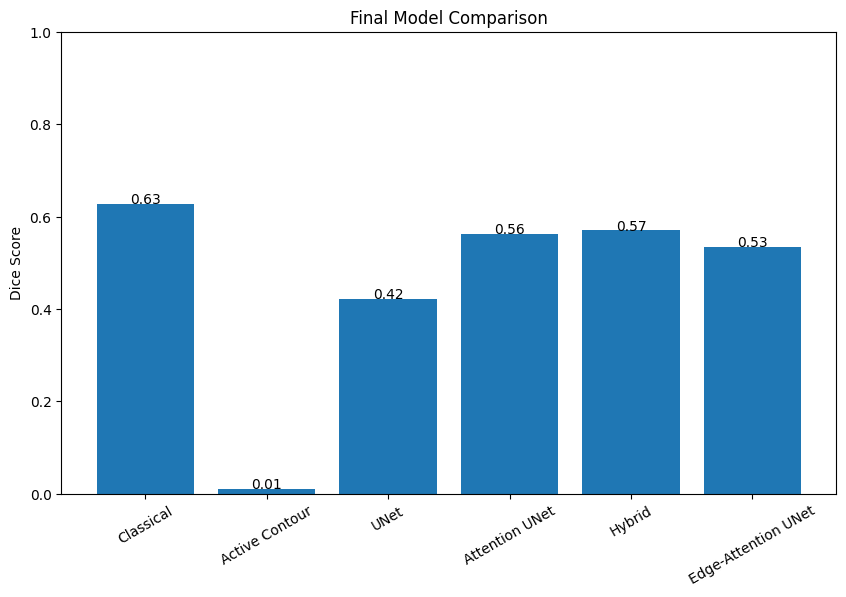

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(models, dice_scores)

plt.title("Final Model Comparison")
plt.ylabel("Dice Score")
plt.xticks(rotation=30)
plt.ylim(0,1)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             h,
             f"{h:.2f}",
             ha='center')

plt.show()

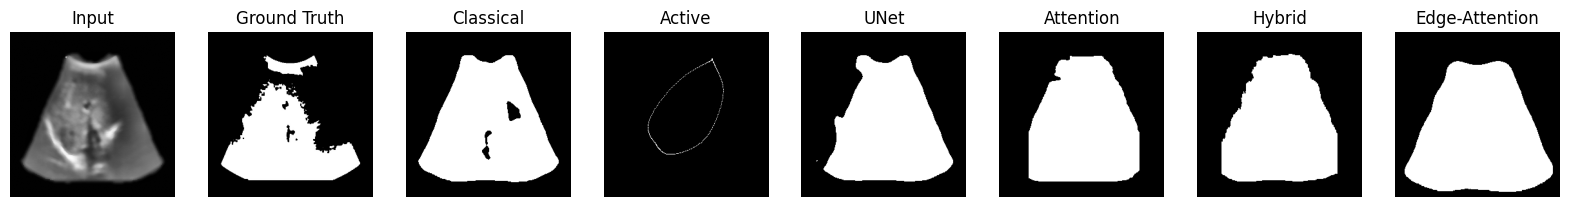

In [121]:
i = 0

plt.figure(figsize=(20,5))

titles = [
    "Input",
    "Ground Truth",
    "Classical",
    "Active",
    "UNet",
    "Attention",
    "Hybrid",
    "Edge-Attention"
]

images = [
    X_test[i].squeeze(),
    Y_test[i].squeeze(),
    classical_segmentation(X_test[i]).squeeze(),
    active_contour_segmentation(X_test[i]).squeeze(),
    preds_bin[i].squeeze(),
    preds_att_bin[i].squeeze(),
    preds_hybrid_bin[i].squeeze(),
    preds_edge_bin[i].squeeze()
]

for j in range(len(images)):
    plt.subplot(1,len(images),j+1)
    plt.imshow(images[j], cmap='gray')
    plt.title(titles[j])
    plt.axis('off')

plt.show()

In [122]:
print("===== FINAL RESULTS =====")

print("Classical Dice:", classical_dice)
print("Active Contour Dice:", active_dice)
print("UNet Dice:", unet_dice)
print("Attention UNet Dice:", attention_unet_dice)
print("Hybrid Dice:", hybrid_dice)
print("Edge-Attention Dice:", np.mean(edge_dice_scores))

===== FINAL RESULTS =====
Classical Dice: 0.62774515
Active Contour Dice: 0.01135618806696536
UNet Dice: 0.4222821808059252
Attention UNet Dice: 0.5631192
Hybrid Dice: 0.5702542
Edge-Attention Dice: 0.5349335


In [123]:
import numpy as np

def compute_metrics(true, pred):

    true = true.flatten()
    pred = pred.flatten()

    TP = np.sum((true == 1) & (pred == 1))
    TN = np.sum((true == 0) & (pred == 0))
    FP = np.sum((true == 0) & (pred == 1))
    FN = np.sum((true == 1) & (pred == 0))

    # Metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)

    precision = TP / (TP + FP + 1e-8)

    recall = TP / (TP + FN + 1e-8)

    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    iou = TP / (TP + FP + FN + 1e-8)

    dice = 2 * TP / (2 * TP + FP + FN + 1e-8)

    return accuracy, precision, recall, f1, iou, dice

In [124]:
unet_metrics = [
    compute_metrics(Y_test[i], preds_bin[i])
    for i in range(len(preds_bin))
]

unet_metrics = np.mean(unet_metrics, axis=0)

In [125]:
classical_metrics = np.mean([
    compute_metrics(Y_test[i],
                    classical_segmentation(X_test[i]))
    for i in range(len(X_test))
], axis=0)

active_metrics = np.mean([
    compute_metrics(Y_test[i],
                    active_contour_segmentation(X_test[i]))
    for i in range(len(X_test))
], axis=0)

attention_metrics = np.mean([
    compute_metrics(Y_test[i],
                    preds_att_bin[i])
    for i in range(len(preds_att_bin))
], axis=0)

hybrid_metrics = np.mean([
    compute_metrics(Y_test[i],
                    preds_hybrid_bin[i])
    for i in range(len(preds_hybrid_bin))
], axis=0)

edge_metrics = np.mean([
    compute_metrics(Y_test[i],
                    preds_edge_bin[i])
    for i in range(len(preds_edge_bin))
], axis=0)

In [126]:
metrics_names = [
    "Accuracy", "Precision",
    "Recall", "F1", "IoU", "Dice"
]

models = {
    "Classical": classical_metrics,
    "Active": active_metrics,
    "UNet": unet_metrics,
    "Attention": attention_metrics,
    "Hybrid": hybrid_metrics,
    "Edge-Attention": edge_metrics
}

for model, values in models.items():
    print("\n", model)
    for name, val in zip(metrics_names, values):
        print(f"{name}: {val:.4f}")


 Classical
Accuracy: 0.8802
Precision: 0.6346
Recall: 0.6548
F1: 0.6404
IoU: 0.5929
Dice: 0.6404

 Active
Accuracy: 0.8033
Precision: 0.5563
Recall: 0.0062
F1: 0.0123
IoU: 0.0062
Dice: 0.0123

 UNet
Accuracy: 0.8822
Precision: 0.6278
Recall: 0.6660
F1: 0.6438
IoU: 0.5984
Dice: 0.6438

 Attention
Accuracy: 0.8244
Precision: 0.5203
Recall: 0.6516
F1: 0.5769
IoU: 0.4924
Dice: 0.5769

 Hybrid
Accuracy: 0.8289
Precision: 0.5268
Recall: 0.6592
F1: 0.5844
IoU: 0.5030
Dice: 0.5844

 Edge-Attention
Accuracy: 0.7794
Precision: 0.4539
Recall: 0.6847
F1: 0.5454
IoU: 0.4477
Dice: 0.5454


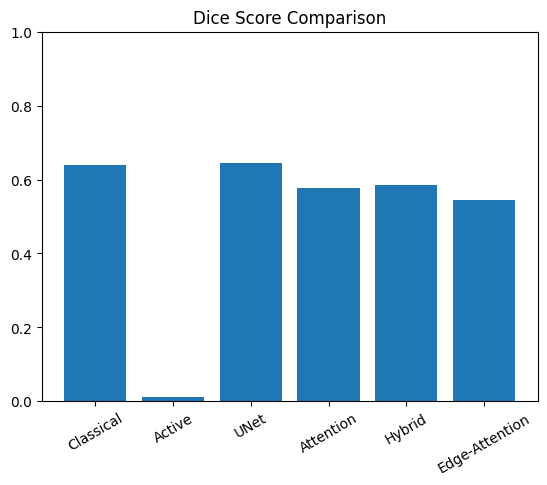

In [127]:
dice_scores = [
    classical_metrics[5],
    active_metrics[5],
    unet_metrics[5],
    attention_metrics[5],
    hybrid_metrics[5],
    edge_metrics[5]
]

plt.bar(models.keys(), dice_scores)
plt.title("Dice Score Comparison")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.show()